# Guaranteed floor -- deliberately as simple as possible

Revisits the no-arbitrage algebraic guarantee from earlier this session, rebuilt from
scratch with everything learned today. Simple enough that it needs NO Black-Scholes
delta, NO volatility estimate, NO leverage-translation factor, NO buffer, NO coverage
band -- just share-matching -- **on the TSLL leg**. (A TSLA fallback is added below for
days TSLL can't fill; see the update note at the bottom of this cell.)

**The guarantee, derived directly**: short N shares of TSLL at price S0, buy N/100
**TSLL** calls (same underlying being shorted -- this is what makes the algebra clean;
using TSLA calls as a leveraged proxy does NOT give this guarantee, since TSLL doesn't
track TSLA 1:1 through daily compounding) at strike K for premium C. Combined payoff:

- If spot ends **above** K at expiry: `P&L = N*(S0-S_T) + N*(S_T-K) - N*C = N*(S0-K-C)` --
  a CONSTANT, independent of how far above K spot goes.
- If spot ends **at or below** K: `P&L = N*(S0-S_T) - N*C`, which is *always* >= the
  constant above (since -S_T >= -K when S_T <= K).

So the worst possible outcome for that cycle is exactly `N*(S0-K-C)`, known and
computable the moment the cycle opens -- not something a backtest has to discover after
the fact. This holds **per cycle** (each ~90-day period where a specific call is held to
its own expiry), not as a single number for the whole multi-year run -- cycles compound,
so a bounded-per-cycle loss does not imply a single bounded lifetime loss. That's stated
honestly below, not glossed over.

**Mechanics -- literally this and nothing else**:
- Short $1 notional TSLL, fixed forever (same buy-and-hold convention as
  `convexity_protection_90dte_sandbox.ipynb`).
- At the start of each cycle, buy `n_shares / 100` **ATM TSLL calls** (share-matched 1:1,
  no delta calculation) with `target_dte=90`.
- Hold to that specific contract's own expiry (no early DTE-forced roll -- the whole point
  is achieving the exact-at-expiry algebra, not an approximation held only close to it).
  `mtm_price()`'s past-expiry branch (`max(spot-strike,0)`) already models this correctly
  -- same convention used everywhere else this session.
- Repeat.

**Update -- TSLA fallback added**: the first run of this notebook found 45.2% of cycles
(14/31) had no real TSLL ATM fill available -- fully naked for nearly half the strategy's
life. Rather than accept that, cycles with no TSLL fill now fall back to a TSLA ATM call,
sized via Black-Scholes delta x `TSLL_LEVER` (same convention as
`convexity_protection_90dte_sandbox.ipynb`). This is a best-effort delta hedge for that
cycle only -- it does NOT carry the algebraic guarantee (TSLL doesn't track TSLA 1:1
through compounding), and is tracked separately (`guaranteed=False` in the cycle log) so
it's never conflated with the proven TSLL cycles. Verification below only checks the
guarantee against TSLL-hedged cycles, as it should.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]  # scripts/utils/ -> project root
sys.path.insert(0, str(ROOT / "scripts" / "eda"))
sys.path.insert(0, str(ROOT / "scripts" / "backtest"))

from data_loader import load_tsll, load_tsll_calls, load_tsla_underlying, load_tsla_calls
from options_selection import select_contract, bs_delta
from metrics import summarize

%matplotlib inline
print("Imports OK")

Imports OK


## Load data -- TSLL spot + TSLL calls only (no TSLA needed at all this time)

In [2]:
tsll_spot = load_tsll().set_index("Date")["Close"]
tsll_calls = load_tsll_calls()
price_lookup = tsll_calls.set_index(["raw_id", "date"])["px_last"].to_dict()

tsla_spot = load_tsla_underlying().set_index("Date")["Close"].reindex(tsll_spot.index).ffill()
tsla_calls = load_tsla_calls()
tsla_price_lookup = tsla_calls.set_index(["raw_id", "date"])["px_last"].to_dict()

dates = tsll_spot.index
print(f"{len(dates):,} trading days, {dates.min().date()} -> {dates.max().date()}")

963 trading days, 2022-08-09 -> 2026-06-10


## Config

In [3]:
TARGET_DTE = 90
MAX_DTE = 110
MONEYNESS_BUCKET = "ATM"
TSLL_LEVER = 2.0   # only used on TSLA-fallback cycles -- best-effort, not the guarantee
R_RF = 0.05
VOL_WINDOW = 21

r_tsla = tsla_spot.pct_change()
tsla_sigma = (r_tsla.rolling(VOL_WINDOW).std() * (252 ** 0.5)).ffill().bfill()

print(f"target_dte={TARGET_DTE}  max_dte={MAX_DTE}  bucket={MONEYNESS_BUCKET}  "
      f"(no roll_dte -- each cycle held to its own expiry)")
print("TSLA fallback active for cycles with no TSLL fill -- best-effort delta hedge, NOT covered by the guarantee")

target_dte=90  max_dte=110  bucket=ATM  (no roll_dte -- each cycle held to its own expiry)
TSLA fallback active for cycles with no TSLL fill -- best-effort delta hedge, NOT covered by the guarantee


## `simulate_guaranteed_floor` -- also records per-cycle (start equity, floor, end equity) for verification

In [4]:
def simulate_guaranteed_floor(sim_dates, spot, calls, price_lookup, moneyness_bucket, target_dte, max_dte,
                               tsla_spot, tsla_calls, tsla_price_lookup, tsla_sigma, notional=1.0):
    """Short N shares TSLL (fixed forever). At each cycle, prefer N/100 TSLL ATM calls
    (share-matched, same underlying -- gives the algebraic guarantee, see markdown). If no
    real TSLL fill is available that day, fall back to a TSLA ATM call sized via
    Black-Scholes delta x TSLL_LEVER (same convention as convexity_protection_90dte_sandbox.ipynb)
    -- best-effort delta hedge for that cycle only, NOT covered by the guarantee, tracked
    separately so the two are never conflated.

    Returns the equity series plus `cycle_log`: one row per cycle with
    (start_date, equity_at_start, floor, end_date, equity_at_end, underlying, guaranteed)."""
    S_incep = float(spot.loc[sim_dates[0]])
    n_shares = notional / S_incep
    n_contracts_tsll = n_shares / 100  # constant forever -- share-matched, never resized

    equity = pd.Series(index=sim_dates, dtype=float)
    position = None   # {"underlying", "raw_id", "strike", "expiry", "n", "price"}
    option_pnl = 0.0
    short_pnl = 0.0
    S_prev = S_incep
    n_unhedged_cycles = 0
    cycle_log = []
    current_cycle = None

    def mtm_price(pos, date):
        spot_series = tsla_spot if pos["underlying"] == "tsla" else spot
        lookup = tsla_price_lookup if pos["underlying"] == "tsla" else price_lookup
        if date > pos["expiry"]:
            return max(float(spot_series.loc[date]) - pos["strike"], 0.0)
        px = lookup.get((pos["raw_id"], date))
        if px is not None and not pd.isna(px):
            return float(px)
        return pos["price"]

    for d in sim_dates:
        S_today = float(spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev = S_today

        need_new_cycle = position is None or d > position["expiry"]

        if position is not None:
            px = mtm_price(position, d)
            option_pnl += position["n"] * 100 * (px - position["price"])
            position["price"] = px

        if need_new_cycle:
            equity_now = notional + short_pnl + option_pnl
            if current_cycle is not None:
                current_cycle["end_date"] = d
                current_cycle["equity_end"] = equity_now
                cycle_log.append(current_cycle)

            row_tsll = select_contract(calls, spot, d, moneyness_bucket, target_dte, max_dte=max_dte)
            if row_tsll is not None:
                entry = float(row_tsll["px_last"])
                position = {"underlying": "tsll", "raw_id": row_tsll["raw_id"], "strike": float(row_tsll["strike"]),
                            "expiry": row_tsll["expiry"], "n": n_contracts_tsll, "price": entry}
                cycle_floor = n_shares * (S_today - float(row_tsll["strike"]) - entry)
                current_cycle = {"start_date": d, "equity_start": equity_now, "floor": cycle_floor,
                                 "underlying": "tsll", "guaranteed": True}
            else:
                # fall back to TSLA, best-effort delta hedge -- no guarantee on this cycle
                row_tsla = select_contract(tsla_calls, tsla_spot, d, moneyness_bucket, target_dte, max_dte=max_dte)
                if row_tsla is not None:
                    S_tsla = float(tsla_spot.loc[d])
                    sigma = float(tsla_sigma.loc[d]) if d in tsla_sigma.index else 0.5
                    T = (row_tsla["expiry"] - d).days / 365.25
                    delta = bs_delta(S_tsla, float(row_tsla["strike"]), T, R_RF, sigma)
                    target_dollar_delta = TSLL_LEVER * n_shares * S_today
                    n_tsla = target_dollar_delta / (max(delta, 0.01) * 100 * S_tsla)
                    entry = float(row_tsla["px_last"])
                    position = {"underlying": "tsla", "raw_id": row_tsla["raw_id"], "strike": float(row_tsla["strike"]),
                                "expiry": row_tsla["expiry"], "n": n_tsla, "price": entry}
                    current_cycle = {"start_date": d, "equity_start": equity_now, "floor": float("nan"),
                                     "underlying": "tsla", "guaranteed": False}
                else:
                    position = None
                    current_cycle = None
                    n_unhedged_cycles += 1

        equity.loc[d] = notional + short_pnl + option_pnl

    if current_cycle is not None:
        current_cycle["end_date"] = sim_dates[-1]
        current_cycle["equity_end"] = equity.iloc[-1]
        cycle_log.append(current_cycle)

    return equity, cycle_log, n_unhedged_cycles

## Run -- full period

In [5]:
equity, cycle_log, n_unhedged_cycles = simulate_guaranteed_floor(
    dates, tsll_spot, tsll_calls, price_lookup, MONEYNESS_BUCKET, TARGET_DTE, MAX_DTE,
    tsla_spot, tsla_calls, tsla_price_lookup, tsla_sigma)

cycle_df = pd.DataFrame(cycle_log)
cycle_df["realized_cycle_pnl"] = cycle_df["equity_end"] - cycle_df["equity_start"]
cycle_df["breach"] = cycle_df["guaranteed"] & (cycle_df["realized_cycle_pnl"] < (cycle_df["floor"] - 1e-6))

row = summarize(equity, equity.pct_change().dropna(), "Guaranteed floor + TSLA fallback")
row["Cycles"] = len(cycle_df)
row["TSLL (guaranteed) cycles"] = int((cycle_df["underlying"] == "tsll").sum())
row["TSLA (best-effort) cycles"] = int((cycle_df["underlying"] == "tsla").sum())
row["Unhedged cycles"] = n_unhedged_cycles

results_df = pd.DataFrame([row])
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
results_df

,Strategy,CAGR,Ann. Vol,Sharpe,Max DD,Calmar,Cycles,TSLL (guaranteed) cycles,TSLA (best-effort) cycles,Unhedged cycles
0,Guaranteed floor + TSLA fallback,0.166318,0.256978,0.730024,-0.221281,0.751614,16,12,4,0


## Equity curve + drawdown

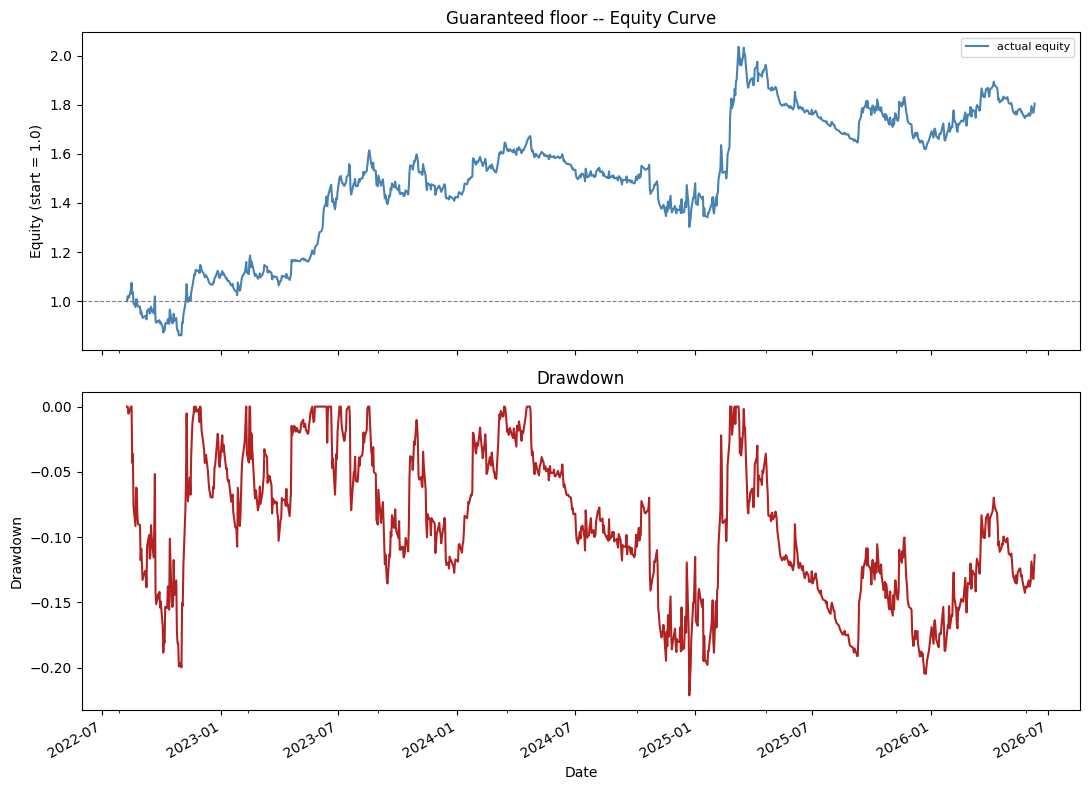

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

equity.plot(ax=axes[0], color="steelblue", label="actual equity")
axes[0].axhline(1.0, color="grey", linestyle="--", linewidth=0.8)
axes[0].set_title("Guaranteed floor -- Equity Curve")
axes[0].set_ylabel("Equity (start = 1.0)")
axes[0].legend(fontsize=8)

dd = equity / equity.cummax() - 1
dd.plot(ax=axes[1], color="firebrick")
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")

fig.tight_layout()
plt.show()

## Verification -- did any cycle's realized P&L ever fall below its OWN stated floor?

In [7]:
n_tsll = int((cycle_df["underlying"] == "tsll").sum())
n_tsla = int((cycle_df["underlying"] == "tsla").sum())
print(f"Cycles: {len(cycle_df)} total  ({n_tsll} TSLL-guaranteed, {n_tsla} TSLA-fallback/best-effort, "
      f"{n_unhedged_cycles} fully unhedged)")
print()
print(cycle_df[["start_date", "end_date", "underlying", "guaranteed", "equity_start", "floor",
                "equity_end", "realized_cycle_pnl", "breach"]].to_string(index=False))

n_breaches = int(cycle_df["breach"].sum())
print(f"\nGuaranteed (TSLL) cycles where realized P&L fell below the stated floor: {n_breaches} / {n_tsll}")

assert equity.isna().sum() == 0, "equity has NaNs"
if n_breaches == 0:
    print("GUARANTEE HELD on every TSLL-hedged cycle. TSLA-fallback cycles are best-effort only, not covered.")
else:
    print("GUARANTEE BROKEN on at least one TSLL-hedged cycle -- see breached rows above.")

print("\nFull result:")
print(results_df.to_string(index=False))

Cycles: 16 total  (12 TSLL-guaranteed, 4 TSLA-fallback/best-effort, 0 fully unhedged)

start_date   end_date underlying  guaranteed  equity_start     floor  equity_end  realized_cycle_pnl  breach
2022-08-09 2022-11-21       tsla       False      1.000000       NaN    1.110526            0.110526   False
2022-11-21 2023-02-21       tsla       False      1.110526       NaN    1.119511            0.008986   False
2023-02-21 2023-04-24       tsll        True      1.119511 -0.084957    1.168413            0.048902   False
2023-04-24 2023-07-24       tsla       False      1.168413       NaN    1.469369            0.300955   False
2023-07-24 2023-09-18       tsll        True      1.469369 -0.077082    1.431242           -0.038127   False
2023-09-18 2023-12-18       tsll        True      1.431242 -0.087857    1.421296           -0.009946   False
2023-12-18 2024-03-18       tsll        True      1.421296 -0.082056    1.614002            0.192706   False
2024-03-18 2024-06-24       tsll        T